# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [6]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [7]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

print(A@e_1)
print(A@e_2)
print(A@e_3)

[1 4 7]
[2 5 8]
[3 6 9]


- 1 (a): A is a 3x3 matrix while each e is a 3x1 vector. Therefore, A@e_1 is a 1x3 vector. For e_1, the first column of each row is selected, for e_2, the second column of each row is selected, and for e_3, the third column of each row is selected as shown above. The product of the not chosen columns is added, but the value is 0.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [8]:
u = np.ones(3)
print(u)
print(A@u)

[1. 1. 1.]
[ 6. 15. 24.]


- 1 (b): u is a 3x1 vector of 1s. When A is multiplied by u, it returns a 1x3 vector of the sum of each row of A as each element of matrix A is selected and added together resulting in a 1x3 vector.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [9]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

print(A@x)

[-2  4 11]


- 1 (c): When x is multiplied by the identity matrix A, it returns the same vector. The identity matrix is a 3x3 matrix with 1s on the diagonal and 0s everywhere else, meaning it will "choose" the corresponding element of x and return a vector of the same length as x with the same values as x, in the same order as [-2,4,11] above.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [10]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

print(A@x)

[11 -2  4]


In [11]:
A = np.array([[1,0,0],
              [0,0,1],
              [0,1,0]])
x = np.array([-6,10,1])

print(A@x)

[-6  1 10]


- 1 (d): When x is multiplied by A, the output is reordered with the values from the the original vector x in a different order, rearranged according setting the orignal vecotrs position in the row according to the column position of the 1 in the A matrix. -2 [0] -> [1], 4 [1] -> [2], 11 [2] -> [0] as above shown above.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [12]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [13]:
print(A@e_1)
print(A@e_2)
print(A@e_3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


- *1 (e): The output of the Markov transition matrix multipled by the vectors e_1, e_2, and e_3, each which has a single 1 in each row, produces vectors of the likelihood of each first value from each row in the Markov transition matrix, for example, A@e_1 provides the first spread of likelihoods of each state in the first row of A.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [14]:
a_1 = A@e_1
a_2 = A@e_2
a_3 = A@e_3

In [15]:
a_1 = A@a_1
a_2 = A@a_2
a_3 = A@a_3

print(a_1)
print(a_2)
print(a_3)

[0.34368862 0.20257047 0.45374091]
[0.28214379 0.29937825 0.41847795]
[0.26334088 0.31930609 0.41735304]


In [16]:
a_1 = A@a_1
a_2 = A@a_2
a_3 = A@a_3

print(a_1)
print(a_2)
print(a_3)

[0.30404142 0.26036337 0.43559521]
[0.29004438 0.28341002 0.42654561]
[0.28521895 0.29032145 0.4244596 ]


In [17]:
a_1 = A@a_1
a_2 = A@a_2
a_3 = A@a_3
a_1 = A@a_1
a_2 = A@a_2
a_3 = A@a_3

print(a_1)
print(a_2)
print(a_3)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


- 1 (f1): The answers for each starting vector is 
    - [0.29266551 0.27862515 0.42870935]
    - [0.29197422 0.27979983 0.42822595]
    - [0.29171646 0.2802254  0.42805814]
- 1 (f2): The behavior of each vector trends towards a [0.29, 0.28, 0.428] distribution for each of the vectors.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [18]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [19]:
t_1 = T@[1,0]
print(t_1)

[0.25 0.75]


- 2 (a): [0.25, 0.75], the value of the first row is 0.25 and the value of the second row is 0.75 as in T for the first row.

In [20]:
t_1 = T@t_1
print(t_1)

[0.4375 0.5625]


- 2 (b): [0.4375, 0.5625] is the output, it is the result of 0.25 times the values of the first row and 0.75 times the values of the second row.
    - 0.25\*0.25 + 0.75\*0.5 = 0.4375 and 0.25\*0.75 + 0.75\*0.5 = 0.5625
    - It’s the distribution after one step: 25% in state 1, 75% in state 2 next period

In [21]:
t_1 = T@t_1
print(t_1)

t_1 = T@t_1
print(t_1)

t_1 = T@t_1
print(t_1)

[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]


- 2 (c): Practically, stability is at 3 decimals by ~5–6 steps

In [22]:
t_2 = T@[0,1]
print(t_2)
t_2 = T@t_2
print(t_2)
t_2 = T@t_2
print(t_2)
t_2 = T@t_2
print(t_2)
t_2 = T@t_2
print(t_2)

[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]


- 2 (d): Different early steps, same long-run limit of [0.4, 0.6]

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [24]:
cville = pd.read_csv('cville_weather.csv')
cville

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [33]:
cville["PRCP"] = pd.to_numeric(cville["PRCP"], errors="coerce")

In [34]:
print("\n=== Missing data counts by column ===")
print(cville.isna().sum())


=== Missing data counts by column ===
STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64


In [37]:
cville["rain"] = (cville["PRCP"] > 0).astype(int)
cville

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,rain
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN,1
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN,1
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN,1
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN,1
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0


In [39]:
ct = pd.crosstab(cville["rain"].shift(1), cville["rain"]).reindex(index=[0,1], columns=[0,1], fill_value=0)
tr_counts = ct.values.astype(float)

row_sums = tr_counts.sum(axis=1, keepdims=True)
P = np.divide(tr_counts, row_sums, out=np.zeros_like(tr_counts), where=row_sums != 0)

print("\n=== 2-state transition matrix P (rows: from, cols: to) ===")
print(pd.DataFrame(P, index=["from_clear(0)", "from_rain(1)"], columns=["to_clear(0)", "to_rain(1)"]))

p_rain_given_clear = P[0, 1]
p_rain_given_rain  = P[1, 1]
print(f"\nP(rain | clear yesterday) = {p_rain_given_clear:.4f}")
print(f"P(rain | rain yesterday)  = {p_rain_given_rain:.4f}")


=== 2-state transition matrix P (rows: from, cols: to) ===
               to_clear(0)  to_rain(1)
from_clear(0)     0.731602    0.268398
from_rain(1)      0.351955    0.648045

P(rain | clear yesterday) = 0.2684
P(rain | rain yesterday)  = 0.6480


In [40]:
def forecast_from_state(P, start_state, steps_list=(1,2,3,5,10,20)):
    """Return a DataFrame with forecasted distribution over {clear, rain}."""
    v0 = np.array([1.0, 0.0]) if start_state == 0 else np.array([0.0, 1.0])
    rows = []
    for n in steps_list:
        vn = v0 @ np.linalg.matrix_power(P, n)  # row vector
        rows.append([n, vn[0], vn[1]])
    out = pd.DataFrame(rows, columns=["steps_ahead", "Pr(clear)", "Pr(rain)"])
    return out

steps = [1, 2, 3, 5, 10, 20]
fc_clear = forecast_from_state(P, start_state=0, steps_list=steps)
fc_rain  = forecast_from_state(P, start_state=1, steps_list=steps)

print("\n=== Forecast starting from a CLEAR day ===")
print(fc_clear.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Forecast starting from a RAINY day ===")
print(fc_rain.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Forecast starting from a CLEAR day ===
 steps_ahead  Pr(clear)  Pr(rain)
           1     0.7316    0.2684
           2     0.6297    0.3703
           3     0.5910    0.4090
           5     0.5708    0.4292
          10     0.5674    0.4326
          20     0.5673    0.4327

=== Forecast starting from a RAINY day ===
 steps_ahead  Pr(clear)  Pr(rain)
           1     0.3520    0.6480
           2     0.4856    0.5144
           3     0.5363    0.4637
           5     0.5629    0.4371
          10     0.5673    0.4327
          20     0.5673    0.4327


It converges roughly around 5-6 steps at 2 decimals, but is floored around 10 steps for both cases for four decimal precision.

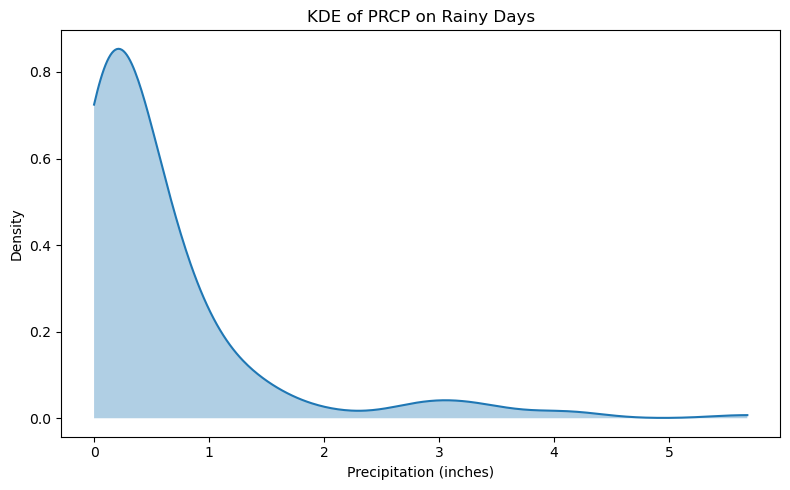

In [41]:
rainy = cville.loc[cville["rain"] == 1, "PRCP"].dropna()
x_grid = np.linspace(0, float(rainy.max()), 400)
kde = gaussian_kde(rainy.values.astype(float))
y = kde(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, y)
plt.fill_between(x_grid, y, alpha=0.35)
plt.title("KDE of PRCP on Rainy Days")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

- One way to improve the model is to expand to multi-state rain intensity (0=clear, 1=light, 2=moderate, 3=heavy) instead of binary.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [25]:
# %%
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [26]:
with open('taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

print(len(data))
data[0]

1000


0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
            ...        
29                 SoHo
29                 SoHo
13    Greenwich Village
3               Chelsea
3               Chelsea
Name: nbhd, Length: 26026, dtype: object

In [27]:
## Extract state space
states = set(data[0])
for i in range(1,len(data)):
    trip_i = set(data[i])
    states = states.union(trip_i)
states = list(states)

- Taxicabs are most likely order 1 because the customer doesn't care where the taxi came from, only where it can take them to. So only the present state, the current location, matters to the customer.

In [28]:
# %%

## Compute transition counts

S = len(states)
tr_counts = np.zeros( (S, S))
        
## Compute transition counts:

for trip in data:
    trip = np.array(trip)
    for t in range(1, len(trip)):
        x_tm1 = trip[t-1]
        x_t = trip[t]
        
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        
        tr_counts[index_from, index_to] += 1

print("Transition Counts:\n", tr_counts)


Transition Counts:
 [[6.00930e+04 2.90000e+02 1.56800e+03 ... 0.00000e+00 1.38660e+04
  7.83000e+02]
 [3.07000e+02 4.65850e+04 1.86000e+02 ... 0.00000e+00 2.19700e+03
  1.66000e+02]
 [1.32300e+03 3.30000e+02 1.39800e+04 ... 2.00000e+00 3.36900e+03
  2.48400e+03]
 ...
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 2.00000e+00 0.00000e+00
  0.00000e+00]
 [1.25610e+04 3.13700e+03 3.43700e+03 ... 1.00000e+00 2.42469e+05
  4.97800e+03]
 [7.86000e+02 3.05000e+02 1.25500e+03 ... 0.00000e+00 5.16200e+03
  1.68380e+04]]


In [29]:
# %%
sums = tr_counts.sum(axis=0, keepdims=True)
print('State proportions: \n')
print(sums)

State proportions: 

[[2.292330e+05 2.171620e+05 1.058730e+05 7.253000e+04 1.431200e+04
  5.790800e+04 3.168490e+05 5.505970e+05 5.077760e+05 1.038800e+04
  3.705660e+05 3.859100e+04 1.627050e+05 1.743220e+05 3.851929e+06
  1.112860e+05 8.740550e+05 3.603000e+03 1.000000e+00 5.102620e+05
  1.224325e+06 5.017430e+05 4.415950e+05 4.086400e+05 2.797713e+06
  3.701250e+05 3.952740e+05 2.363961e+06 4.930000e+02 1.803491e+06
  3.000000e+00 8.010000e+03 1.978283e+06 8.886440e+05 6.543970e+05
  1.200000e+01 8.393620e+05 1.063770e+05]]


In [30]:
row_sums = tr_counts.sum(axis=1, keepdims=True)
P = np.divide(tr_counts, row_sums, out=np.zeros_like(tr_counts), where=row_sums!=0)

hk = states.index("Hell's Kitchen")
v0 = np.zeros(len(states))
v0[hk] = 1.0 

def forecast(v, steps):
    return v @ np.linalg.matrix_power(P, steps)

for k in [2, 3, 5, 10]:
    vk = forecast(v0, k)
    s = pd.Series(vk, index=states).sort_values(ascending=False)
    print(f"\nTop destinations after {k} trips from Hell's Kitchen:")
    print(s.head(8).round(3)) 


Top destinations after 2 trips from Hell's Kitchen:
Midtown              0.173
Hell's Kitchen       0.119
Chelsea              0.109
Upper West Side      0.099
Upper East Side      0.087
Outside Manhattan    0.078
Theater District     0.060
West Village         0.035
dtype: float64

Top destinations after 3 trips from Hell's Kitchen:
Midtown              0.173
Upper East Side      0.108
Chelsea              0.097
Upper West Side      0.092
Outside Manhattan    0.090
Hell's Kitchen       0.075
Theater District     0.047
West Village         0.036
dtype: float64

Top destinations after 5 trips from Hell's Kitchen:
Midtown              0.169
Upper East Side      0.120
Outside Manhattan    0.099
Chelsea              0.088
Upper West Side      0.083
Hell's Kitchen       0.057
Theater District     0.040
East Village         0.037
dtype: float64

Top destinations after 10 trips from Hell's Kitchen:
Midtown              0.168
Upper East Side      0.122
Outside Manhattan    0.103
Chelsea      

Transition Proportions:

                     Battery Park City  Harlem  Chinatown  Washington Heights  \
Battery Park City                 0.26    0.00       0.01                0.00   
Harlem                            0.00    0.21       0.00                0.04   
Chinatown                         0.01    0.00       0.13                0.00   
Washington Heights                0.00    0.05       0.00                0.15   
Inwood                            0.00    0.01       0.00                0.02   
Civic Center                      0.01    0.00       0.02                0.00   
East Harlem                       0.00    0.06       0.00                0.02   
SoHo                              0.04    0.01       0.05                0.01   
Kips Bay                          0.01    0.01       0.01                0.01   
Two Bridges                       0.00    0.00       0.01                0.00   
Lower East Side                   0.01    0.01       0.06                0.01   
Lit

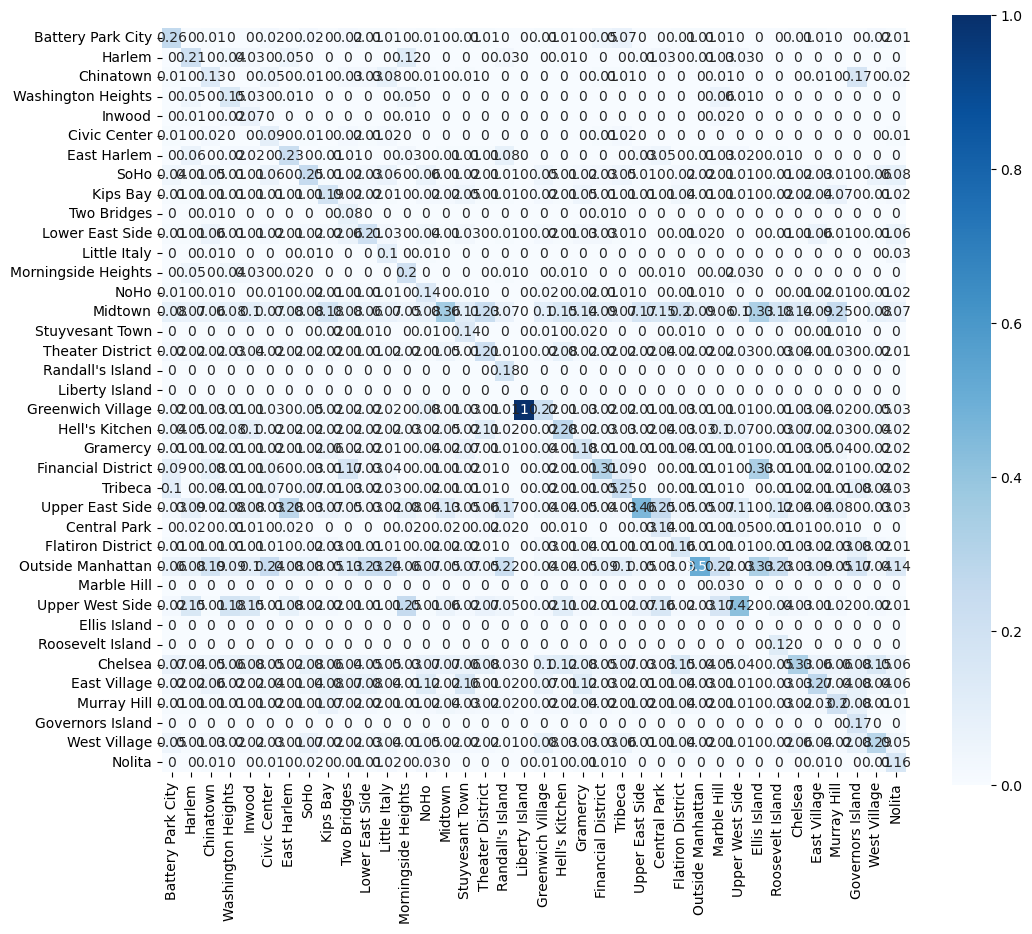

In [31]:
## Normalize the transition count matrix to get proportions
tr_pr = np.divide(tr_counts, sums, 
            out=np.zeros_like(tr_counts), 
            where=sums!=0)

print("Transition Proportions:\n")
tr_df = pd.DataFrame(np.round(tr_pr, 2), index=states, columns=states)
print(tr_df)

plt.figure(figsize=(12, 10))
sns.heatmap(tr_df, 
            cmap='Blues',
            square=True,
            xticklabels=states,
            yticklabels=states,
            annot=True)
plt.show()

- Outside Manhattan: ~0.51 stay, 
- Upper East Side: ~0.46 stay, 
- Midtown: ~0.36 stay, 
- Chelsea: ~0.33 stay
- Theater District: ~0.21 stay
- Upper West Side: ~0.17 stay

Based on the top "stays" for each box on the diagonal, it appears cabs mostly stay in these areas.